# GAIL — Generative Adversarial Imitation Learning (Google Colab)

Trains a PPO generator via **GAIL** ([docs](https://imitation.readthedocs.io/en/latest/algorithms/gail.html)) on human demonstrations for the `OpenElectricKettleLid` task.

### What GAIL does differently from plain BC
| | BC (MSE) | GAIL |
|---|---|---|
| Training signal | Supervised MSE on actions | Discriminator reward (adversarial) |
| Env interaction | None (offline) | Yes — PPO rolls out in the env |
| Distribution shift | Prone to compounding errors | More robust |
| Cost | Very cheap | Moderate (needs RL loop) |

### Steps
1. GPU check
2. Clone repo → branch `b313`
3. Install dependencies
4. Download dataset (`~200 MB`)
5. Configure paths
6. Train GAIL
7. Results + plots
8. Save to Google Drive *(optional)*

> **Runtime:** `Runtime → Change runtime type → T4 GPU` before starting.

---
## 1. GPU Check

In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if r.returncode == 0:
    print(r.stdout)
else:
    print('⚠️  No GPU detected — training will use CPU (much slower).')

Fri Apr  3 19:12:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   37C    P0             72W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

---
## 2. Clone Repository

In [2]:
# Fill in a GitHub PAT only if the repo is private.
GITHUB_TOKEN = ''   # e.g. 'ghp_xxxxxxxxxxxxxxxxxxxx'

REPO    = 'sergio-contente/RoboCasa-Project'
BRANCH  = 'b313'
WORKDIR = '/content/RoboCasa-Project'

import os, subprocess

if GITHUB_TOKEN:
    clone_url = f'https://{GITHUB_TOKEN}@github.com/{REPO}.git'
else:
    clone_url = f'https://github.com/{REPO}.git'

if not os.path.isdir(WORKDIR):
    subprocess.run(
        ['git', 'clone', '--recurse-submodules', '-b', BRANCH, clone_url, WORKDIR],
        check=True
    )
else:
    print(f'{WORKDIR} already exists — pulling.')
    subprocess.run(['git', '-C', WORKDIR, 'pull'], check=True)
    subprocess.run(
        ['git', '-C', WORKDIR, 'submodule', 'update', '--init', '--recursive'],
        check=True
    )

result = subprocess.run(
    ['git', '-C', WORKDIR, 'log', '--oneline', '-3'],
    capture_output=True, text=True
)
print(result.stdout)

f540154 ✨
79959eb ✨
0b0ddaa 🚧  BC



---
## 3. Install Dependencies

> **After this cell finishes, the kernel must be restarted.** A helper cell at the end of this section does it automatically.

In [3]:
import os, subprocess
WORKDIR = '/content/RoboCasa-Project'

# robosuite must be installed before robocasa (robocasa depends on it)
print('Installing robosuite...')
os.system(f'pip install -e {WORKDIR}/deps/robosuite -q')

print('Installing robocasa...')
os.system(f'pip install -e {WORKDIR}/deps/robocasa -q')

# imitation==1.0.1 requires stable-baselines3==2.2.1
print('Installing imitation + compatible stable-baselines3...')
os.system('pip install "imitation==1.0.1" "stable-baselines3==2.2.1" -q')

print('Installing remaining utilities...')
os.system('pip install pyarrow -q')

# Set up robocasa macros (we override DATASET_BASE_PATH in Section 4)
print('Setting up robocasa macros...')
subprocess.run(
    ['python', '-m', 'robocasa.scripts.setup_macros'],
    input='y\n', text=True, cwd=WORKDIR,
)

# Download kitchen visual assets (textures, meshes) required by the simulator
print('Downloading kitchen assets...')
subprocess.run(
    ['python', '-m', 'robocasa.scripts.download_kitchen_assets'],
    input='y\n', text=True, cwd=WORKDIR,
)

print('\nAll done. Restarting kernel...')

Installing robosuite...
Installing robocasa...
Installing imitation + compatible stable-baselines3...
Installing remaining utilities...
Setting up robocasa macros...

All done. Restarting kernel...


In [ ]:
# Restart kernel so installs are active. Continue from Section 4 after restart.
import os; os.kill(os.getpid(), 9)

---
## 4. Download Dataset

Downloads the `pretrain / human` split (~200 MB) using the official RoboCasa download script.

In [1]:
import os, sys, subprocess
WORKDIR      = '/content/RoboCasa-Project'
DATASET_BASE = '/content/datasets'
os.makedirs(DATASET_BASE, exist_ok=True)

# Point RoboCasa to our dataset folder (must happen before the first robocasa import)
import robocasa
macros_private = os.path.join(robocasa.__path__[0], 'macros_private.py')
with open(macros_private, 'w') as f:
    f.write(f'DATASET_BASE_PATH = "{DATASET_BASE}"\n')
print(f'DATASET_BASE_PATH = {DATASET_BASE}')

DATASET_PATH = (
    f'{DATASET_BASE}/v1.0/pretrain/atomic/OpenElectricKettleLid/20250820/lerobot'
)

if os.path.isdir(os.path.join(DATASET_PATH, 'data')):
    n = len(list(__import__('pathlib').Path(DATASET_PATH).glob('data/*/episode_*.parquet')))
    print(f'Dataset already present — {n} episodes found.')
else:
    print('Downloading dataset (pretrain / human)...')
    result = subprocess.run(
        [
            'python', '-m', 'robocasa.scripts.download_datasets',
            '--tasks',  'OpenElectricKettleLid',
            '--split',  'pretrain',
            '--source', 'human',
        ],
        input='y\n',         # answer the interactive "Proceed? (y/n)" prompt
        text=True,
        capture_output=False,
        env={**os.environ, 'ROBOCASA_DATASET_BASE_PATH': DATASET_BASE},
    )
    if result.returncode != 0:
        raise RuntimeError('Dataset download failed — check output above.')
    print('Download complete.')

[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /content/RoboCasa-Project/deps/robosuite/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly (e.g. pip install mink==0.0.5), otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


DATASET_BASE_PATH = /content/datasets
Download complete.


In [2]:
# Verify dataset structure
from pathlib import Path
ds = Path(DATASET_PATH)
print('Dataset structure:')
for d in ['data', 'extras', 'meta']:
    status = '✓' if (ds / d).is_dir() else '✗ missing'
    print(f'  {d}/  {status}')

episodes = list(ds.glob('data/*/episode_*.parquet'))
print(f'\nEpisodes: {len(episodes)}')
print(f'modality.json: {"✓" if (ds / "meta" / "modality.json").exists() else "✗ (bundled fallback will be used)"}')

Dataset structure:
  data/  ✓
  extras/  ✓
  meta/  ✓

Episodes: 110
modality.json: ✓


---
## 5. Configure Project Paths

In [3]:
import sys, os
WORKDIR      = '/content/RoboCasa-Project'
DATASET_BASE = '/content/datasets'
OUTPUT_DIR   = f'{WORKDIR}/results'

os.chdir(WORKDIR)
if WORKDIR not in sys.path:
    sys.path.insert(0, WORKDIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Working dir  : {os.getcwd()}')
print(f'Dataset base : {DATASET_BASE}')
print(f'Results dir  : {OUTPUT_DIR}')

import torch
print(f'Device       : {"cuda" if torch.cuda.is_available() else "cpu"}')

Working dir  : /content/RoboCasa-Project
Dataset base : /content/datasets
Results dir  : /content/RoboCasa-Project/results
Device       : cuda


---
## 6. Hyperparameters

In [6]:
# ── Edit before training ──────────────────────────────────────────────────
N_DEMO_EPISODES  = 30       # expert episodes to load
TOTAL_TIMESTEPS  = 100_000  # total GAIL training timesteps
N_ENVS           = 4        # parallel environments for PPO rollouts
LEARNING_RATE    = 3e-4
N_STEPS          = 512     # PPO steps per env per update
BATCH_SIZE       = 256      # PPO mini-batch size
DEMO_BATCH       = 256     # expert transitions per discriminator update
N_DISC_UPDATES   = 4        # discriminator gradient steps per round
N_EVAL_EPISODES  = 10       # rollout episodes after training
# ─────────────────────────────────────────────────────────────────────────

---
## 7. Train GAIL

Each *round* alternates between:
1. **Generator step** — PPO collects `N_STEPS × N_ENVS` transitions; reward from discriminator
2. **Discriminator step** — `N_DISC_UPDATES` gradient steps classifying expert vs learner

In [7]:
import train_gail
import importlib; importlib.reload(train_gail)

train_gail.main([
    '--episodes',       str(N_DEMO_EPISODES),
    '--timesteps',      str(TOTAL_TIMESTEPS),
    '--n-envs',         str(N_ENVS),
    '--lr',             str(LEARNING_RATE),
    '--n-steps',        str(N_STEPS),
    '--batch-size',     str(BATCH_SIZE),
    '--demo-batch',     str(DEMO_BATCH),
    '--n-disc-updates', str(N_DISC_UPDATES),
    '--eval-ep',        str(N_EVAL_EPISODES),
    '--dataset-root',   DATASET_BASE,
    '--output',         OUTPUT_DIR,
])

[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json
[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json
[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robos

Using cuda device
Running with `allow_variable_horizon` set to True. Some algorithms are biased towards shorter or longer episodes, which may significantly confound results. Additionally, even unbiased algorithms can exploit the information leak from the termination condition, producing spuriously high performance. See https://imitation.readthedocs.io/en/latest/getting-started/variable-horizon.html for more information.


round:   0%|          | 0/48 [00:00<?, ?it/s]

--------------------------------------
| raw/                        |      |
|    gen/time/fps             | 18   |
|    gen/time/iterations      | 1    |
|    gen/time/time_elapsed    | 113  |
|    gen/time/total_timesteps | 2048 |
--------------------------------------
--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 0.521    |
|    disc/disc_acc_expert             | 0.0469   |
|    disc/disc_acc_gen                | 0.996    |
|    disc/disc_entropy                | 0.692    |
|    disc/disc_loss                   | 0.689    |
|    disc/disc_proportion_expert_pred | 0.0254   |
|    disc/disc_proportion_expert_true | 0.5      |
|    disc/global_step                 | 1        |
|    disc/n_expert                    | 256      |
|    disc/n_generated                 | 256      |
--------------------------------------------------
--------------------------------------------------
| raw/       

round:   2%|▏         | 1/48 [01:53<1:29:05, 113.73s/it]

...

round:  96%|█████████▌| 46/48 [1:12:31<03:16, 98.13s/it]

----------------------------------------------------
| raw/                               |             |
|    gen/rollout/ep_rew_wrapped_mean | 88.1        |
|    gen/time/fps                    | 19          |
|    gen/time/iterations             | 1           |
|    gen/time/time_elapsed           | 103         |
|    gen/time/total_timesteps        | 96256       |
|    gen/train/approx_kl             | 0.059130505 |
|    gen/train/clip_fraction         | 0.472       |
|    gen/train/clip_range            | 0.2         |
|    gen/train/entropy_loss          | -16.4       |
|    gen/train/explained_variance    | 0.58600056  |
|    gen/train/learning_rate         | 0.0003      |
|    gen/train/loss                  | 0.457       |
|    gen/train/n_updates             | 460         |
|    gen/train/policy_gradient_loss  | -0.0805     |
|    gen/train/std                   | 0.952       |
|    gen/train/value_loss            | 2.49        |
----------------------------------------------

round:  98%|█████████▊| 47/48 [1:14:15<01:39, 99.83s/it]

---------------------------------------------------
| raw/                               |            |
|    gen/rollout/ep_rew_wrapped_mean | 84.9       |
|    gen/time/fps                    | 19         |
|    gen/time/iterations             | 1          |
|    gen/time/time_elapsed           | 107        |
|    gen/time/total_timesteps        | 98304      |
|    gen/train/approx_kl             | 0.07913394 |
|    gen/train/clip_fraction         | 0.46       |
|    gen/train/clip_range            | 0.2        |
|    gen/train/entropy_loss          | -16.4      |
|    gen/train/explained_variance    | 0.8413615  |
|    gen/train/learning_rate         | 0.0003     |
|    gen/train/loss                  | 0.132      |
|    gen/train/n_updates             | 470        |
|    gen/train/policy_gradient_loss  | -0.0818    |
|    gen/train/std                   | 0.951      |
|    gen/train/value_loss            | 1.55       |
---------------------------------------------------
------------

round: 100%|██████████| 48/48 [1:16:02<00:00, 95.06s/it] 
[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


---
## 8. Results

In [8]:
import json
from pathlib import Path

eval_file = Path(OUTPUT_DIR) / 'gail_eval.json'
if not eval_file.exists():
    print('gail_eval.json not found — run Section 7 first.')
else:
    metrics = json.loads(eval_file.read_text())
    print('GAIL Evaluation Results (true environment reward)')
    print('─' * 40)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f'  {k:<28}: {v:.4f}')
        else:
            print(f'  {k:<28}: {v}')

GAIL Evaluation Results (true environment reward)
────────────────────────────────────────
  success_rate                : 0.0000
  avg_lid_progress            : 0.0000
  std_lid_progress            : 0.0000
  avg_reward                  : 0.0000
  avg_episode_length          : 500.0000
  n_episodes                  : 10


In [9]:
# Visualise discriminator log (reward proxy over time)
import matplotlib.pyplot as plt
import os

log_dir = os.path.join(OUTPUT_DIR, 'gail_logs')
monitor_files = list(Path(log_dir).glob('**/*.monitor.csv')) if os.path.isdir(log_dir) else []

if monitor_files:
    import pandas as pd
    df = pd.concat([pd.read_csv(f, skiprows=1) for f in monitor_files])
    df = df.sort_values('t')

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(df['t'], df['r'].rolling(50, min_periods=1).mean(),
            color='#4C72B0', linewidth=1.5, label='Disc. reward (rolling 50)')
    ax.set_xlabel('Wall-clock time (s)')
    ax.set_ylabel('Episode reward (discriminator)')
    ax.set_title('GAIL — Generator Discriminator Reward', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/gail_disc_reward.png', dpi=150)
    plt.show()
else:
    print('No monitor logs found — reward curve unavailable.')

No monitor logs found — reward curve unavailable.


---
## 9. Save to Google Drive *(optional)*

In [10]:
SAVE_TO_DRIVE = True         # ← set True to enable
DRIVE_FOLDER  = 'MyDrive/RoboCasa'

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    import shutil
    dest = f'/content/drive/{DRIVE_FOLDER}'
    os.makedirs(dest, exist_ok=True)

    for fname in ['gail_model.zip', 'gail_eval.json', 'gail_disc_reward.png']:
        src = Path(OUTPUT_DIR) / fname
        if src.exists():
            shutil.copy(src, dest)
            print(f'Copied {fname} → {dest}')
else:
    print('Drive save skipped (set SAVE_TO_DRIVE = True to enable).')

Mounted at /content/drive
Copied gail_model.zip → /content/drive/MyDrive/RoboCasa
Copied gail_eval.json → /content/drive/MyDrive/RoboCasa


In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Evaluate GAIL model (collect per-timestep rewards)
# ═══════════════════════════════════════════════════════════════════

import numpy as np
from pathlib import Path
from stable_baselines3 import PPO
from gym_wrapper import make_env

# ── Config ──
MODEL_PATH = Path(OUTPUT_DIR) / "gail_model.zip"
# If model was saved to Drive and runtime was reset:
# MODEL_PATH = Path("/content/drive/MyDrive/RoboCasa/gail_model.zip")
N_EVAL = 20
MAX_STEPS = 500

# ── Load model ──
model = PPO.load(MODEL_PATH)
print(f"Loaded model from {MODEL_PATH}")

# ── Run episodes ──
all_rewards = []
all_lid     = []

for ep in range(N_EVAL):
    env = make_env(reward_mode="dense", seed=ep)
    obs, _ = env.reset()

    ep_rewards = []
    ep_lid     = []

    for t in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        ep_rewards.append(float(reward))
        ep_lid.append(float(info.get("lid_progress", 0.0)))
        if terminated or truncated:
            break

    all_rewards.append(np.array(ep_rewards))
    all_lid.append(np.array(ep_lid))
    env.close()
    print(f"  Episode {ep+1:>2}/{N_EVAL} — steps={len(ep_rewards)}, "
          f"total_reward={sum(ep_rewards):.4f}, max_lid={max(ep_lid):.4f}")

# Pad to MAX_STEPS for plotting
def pad(arr_list, length, fill=0.0):
    return np.array([
        np.pad(a, (0, length - len(a)), constant_values=fill)
        for a in arr_list
    ])

rewards_matrix = pad(all_rewards, MAX_STEPS)
lid_matrix     = pad(all_lid, MAX_STEPS)

print(f"\nDone. Success rate: "
      f"{np.mean([l[-1] >= 0.95 for l in all_lid]):.0%}")



[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


Loaded model from /content/RoboCasa-Project/results/gail_model.zip


[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


  Episode  1/20 — steps=500, total_reward=0.0000, max_lid=0.0000


[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


...

  Episode 17/20 — steps=500, total_reward=0.0000, max_lid=0.0000


[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


  Episode 18/20 — steps=500, total_reward=0.0000, max_lid=0.0000


[robosuite INFO] Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json (composite_controller_factory.py:121)
INFO:robosuite_logs:Loading controller configuration from: /content/RoboCasa-Project/deps/robosuite/robosuite/controllers/config/robots/default_pandaomron.json


  Episode 19/20 — steps=500, total_reward=0.0000, max_lid=0.0000
  Episode 20/20 — steps=500, total_reward=0.0000, max_lid=0.0000

Done. Success rate: 0%


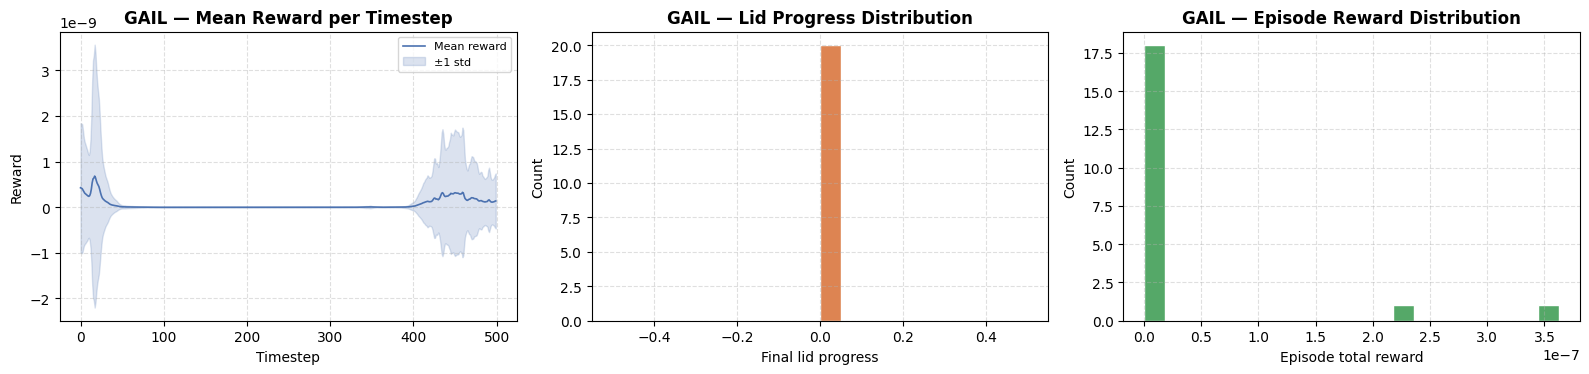

Saved → /content/RoboCasa-Project/results/gail_eval_plots.png


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Plot reward per timestep + lid progress
# ═══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Mean reward per timestep
ax = axes[0]
mean_r = rewards_matrix.mean(axis=0)
std_r  = rewards_matrix.std(axis=0)
steps  = np.arange(MAX_STEPS)
ax.plot(steps, mean_r, color="#4C72B0", linewidth=1.2, label="Mean reward")
ax.fill_between(steps, mean_r - std_r, mean_r + std_r,
                color="#4C72B0", alpha=0.2, label="±1 std")
ax.set_xlabel("Timestep")
ax.set_ylabel("Reward")
ax.set_title("GAIL — Mean Reward per Timestep", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)

# 2. Lid progress distribution
ax = axes[1]
final_lid = [l[-1] for l in all_lid]
ax.hist(final_lid, bins=20, color="#DD8452", edgecolor="white")
ax.set_xlabel("Final lid progress")
ax.set_ylabel("Count")
ax.set_title("GAIL — Lid Progress Distribution", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4)

# 3. Episode reward distribution
ax = axes[2]
ep_totals = [r.sum() for r in all_rewards]
ax.hist(ep_totals, bins=20, color="#55A868", edgecolor="white")
ax.set_xlabel("Episode total reward")
ax.set_ylabel("Count")
ax.set_title("GAIL — Episode Reward Distribution", fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gail_eval_plots.png", dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/gail_eval_plots.png")


---
## Summary

| File | Description |
|------|-------------|
| `results/gail_model.zip` | Trained PPO generator — load with `PPO.load(path)` |
| `results/gail_eval.json` | Final evaluation metrics (true env reward) |
| `results/gail_logs/` | Training logs (discriminator, generator losses) |

### How to load the model later
```python
from stable_baselines3 import PPO
model = PPO.load('results/gail_model')
action, _ = model.predict(obs, deterministic=True)
```

### Next steps
Fine-tune the GAIL policy with dense reward or curriculum learning using `train_il_rl_rs.py` — pass `--bc-model` with the generator weights extracted from `gail_model.zip`.